<center><a target="_blank" href="https://academy.constructor.org/"><img src=https://lh3.googleusercontent.com/d/1fypIr9T-7ntcsVQFmC2_iMPcsm7h8jXg width="500" style="background:none; border:none; box-shadow:none;" /></a> </center>
<hr />

# <h1 align="center"> Day-1-Descriptive-Statistics. Exercise session 3: Scaling and Normalization </h1> </center>

<p style="margin-bottom:1cm;"></p>

_____

<center>Constructor Nexademy, 2026</center>




## Scaling and Normalization

For this exercise on scaling and normalization, we have a look at the column “history” from the marketing dataset. This column contains the global revenue generated by each customer (each row corresponds to one customer).

1. Read the data from the Marketing csv file and extract the history column from it

In [1]:
# in soal sade sazie masalan yeki az 20 - 10 gerefte yeki az 100 - 50 gerefte, pas behtare ke az raveshe random sampling estefade konim ta inke har doye anha dar train va test bashan va behtare ke random_state ro ham set konim ta har bar ke code ro run mikonim hamun natije ro bedast biarim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Marketing3.csv
data_file = 'https://drive.google.com/uc?export=download&id=1-6CGpOFdmZ8vOz3OrCXZC170q1zJDJtQ'
df = pd.read_csv(data_file)
df

,Unnamed: 0,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0
1,1,5,349.41,1,1,Surburban,1,Phone,Buy One Get One,0
2,2,7,64.04,0,1,Rural,0,Web,Buy One Get One,1
3,3,2,244.82,0,1,Rural,1,Web,Buy One Get One,1
4,4,11,302.15,1,0,Urban,0,Web,Buy One Get One,0
...,...,...,...,...,...,...,...,...,...,...
63995,63995,9,135.36,1,0,Urban,1,Phone,No Offer,0
63996,63996,3,74.42,0,1,Rural,1,Web,No Offer,0
63997,63997,10,279.57,1,0,Rural,1,Web,No Offer,1
63998,63998,10,44.46,1,0,Rural,0,Web,No Offer,0


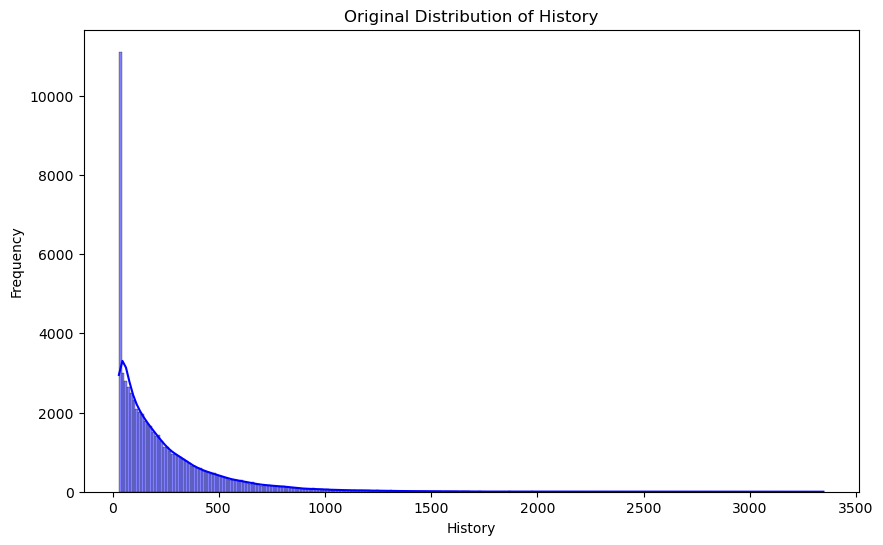

Minimum History: 29.99
Maximum History: 3345.93
Mean History: 242.08565578124998


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['history'], kde=True, color='blue')
plt.title('Original Distribution of History')
plt.xlabel('History')
plt.ylabel('Frequency') 
plt.show()

print("Minimum History:", df['history'].min())
print("Maximum History:", df['history'].max())
print("Mean History:", df['history'].mean())

2. Write a function for MinMaxScaling, Standardization, and log scaling

In [5]:
def LogScaling(x):
    return np.log(x)


def MinMaxScaling(x):
    return(x-np.min(x))/(np.max(x)-np.min(x))


def Standardize(x):
    return (x - np.mean(x)) / np.std(x)

3. Apply written functions to the marketing history

In [6]:
df['history_log'] = LogScaling(df['history'])
df['history_minmax'] = MinMaxScaling(df['history'])
df['history_standardized'] = Standardize(df['history'])
print("---- Compare of scaling meth----")
print(df[['history', 'history_log', 'history_minmax', 'history_standardized']].head())

---- Compare of scaling meth----
   history  history_log  history_minmax  history_standardized
0   142.44     4.958921        0.033912             -0.389003
1   349.41     5.856246        0.096329              0.418979
2    64.04     4.159508        0.010269             -0.695066
3   244.82     5.500523        0.064787              0.010675
4   302.15     5.710924        0.082076              0.234483


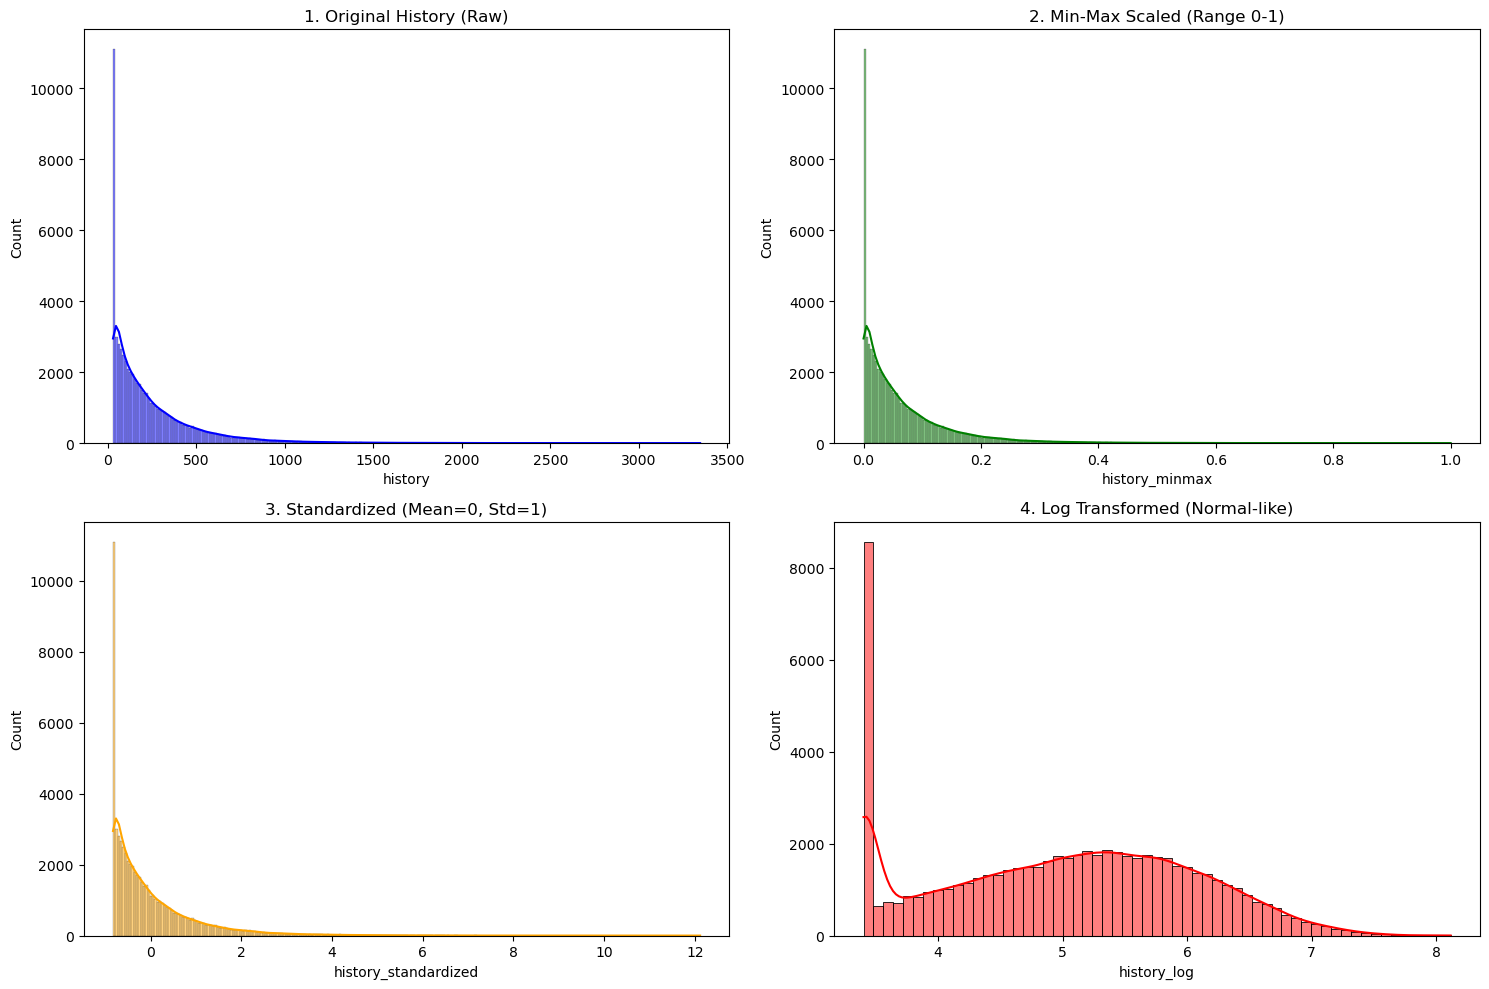

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['history'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('1. Original History (Raw)')

sns.histplot(df['history_minmax'], kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('2. Min-Max Scaled (Range 0-1)')

sns.histplot(df['history_standardized'], kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('3. Standardized (Mean=0, Std=1)')

sns.histplot(df['history_log'], kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('4. Log Transformed (Normal-like)')

plt.tight_layout()
plt.show()

4. Make a density plot of all random sample, scaled, standardized and log transformed data and compare the effect

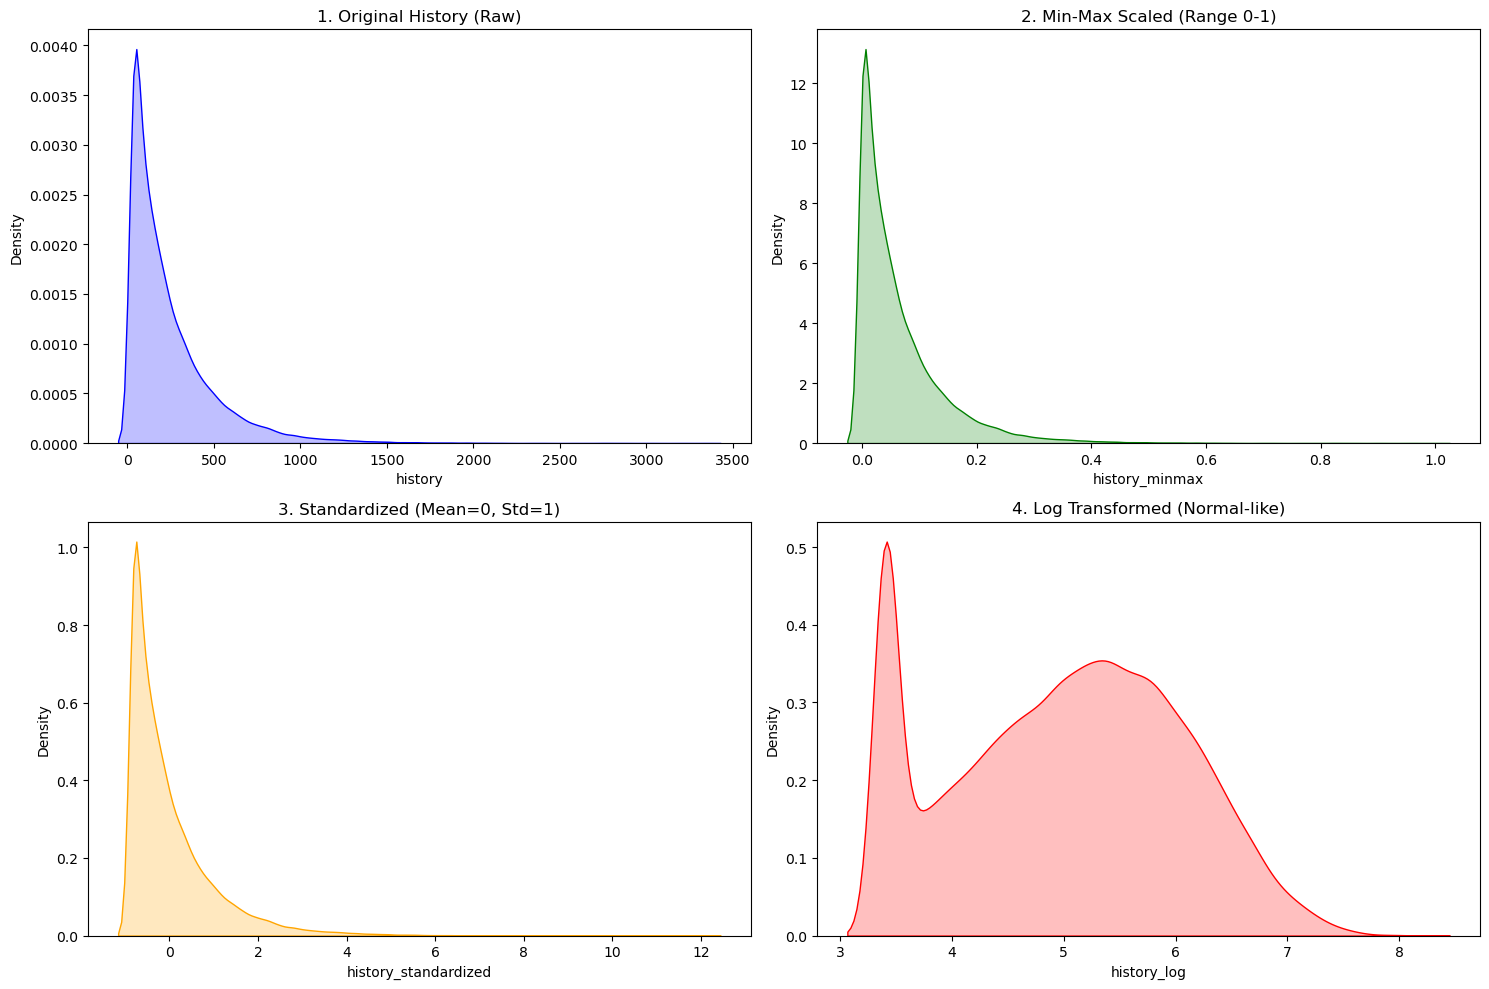

In [12]:
df['history_log'] = LogScaling(df['history'])
df['history_minmax'] = MinMaxScaling(df['history'])
df['history_standardized'] = Standardize(df['history'])
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


#original
sns.kdeplot(df['history'], fill=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('1. Original History (Raw)')

#min
sns.kdeplot(df['history_minmax'], fill=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('2. Min-Max Scaled (Range 0-1)')

#standardize
sns.kdeplot(df['history_standardized'], fill=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('3. Standardized (Mean=0, Std=1)')

#log
sns.kdeplot(df['history_log'], fill=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('4. Log Transformed (Normal-like)')
plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>

**5. Bonus - Make a violin plot of sample, scaled and standardized data**

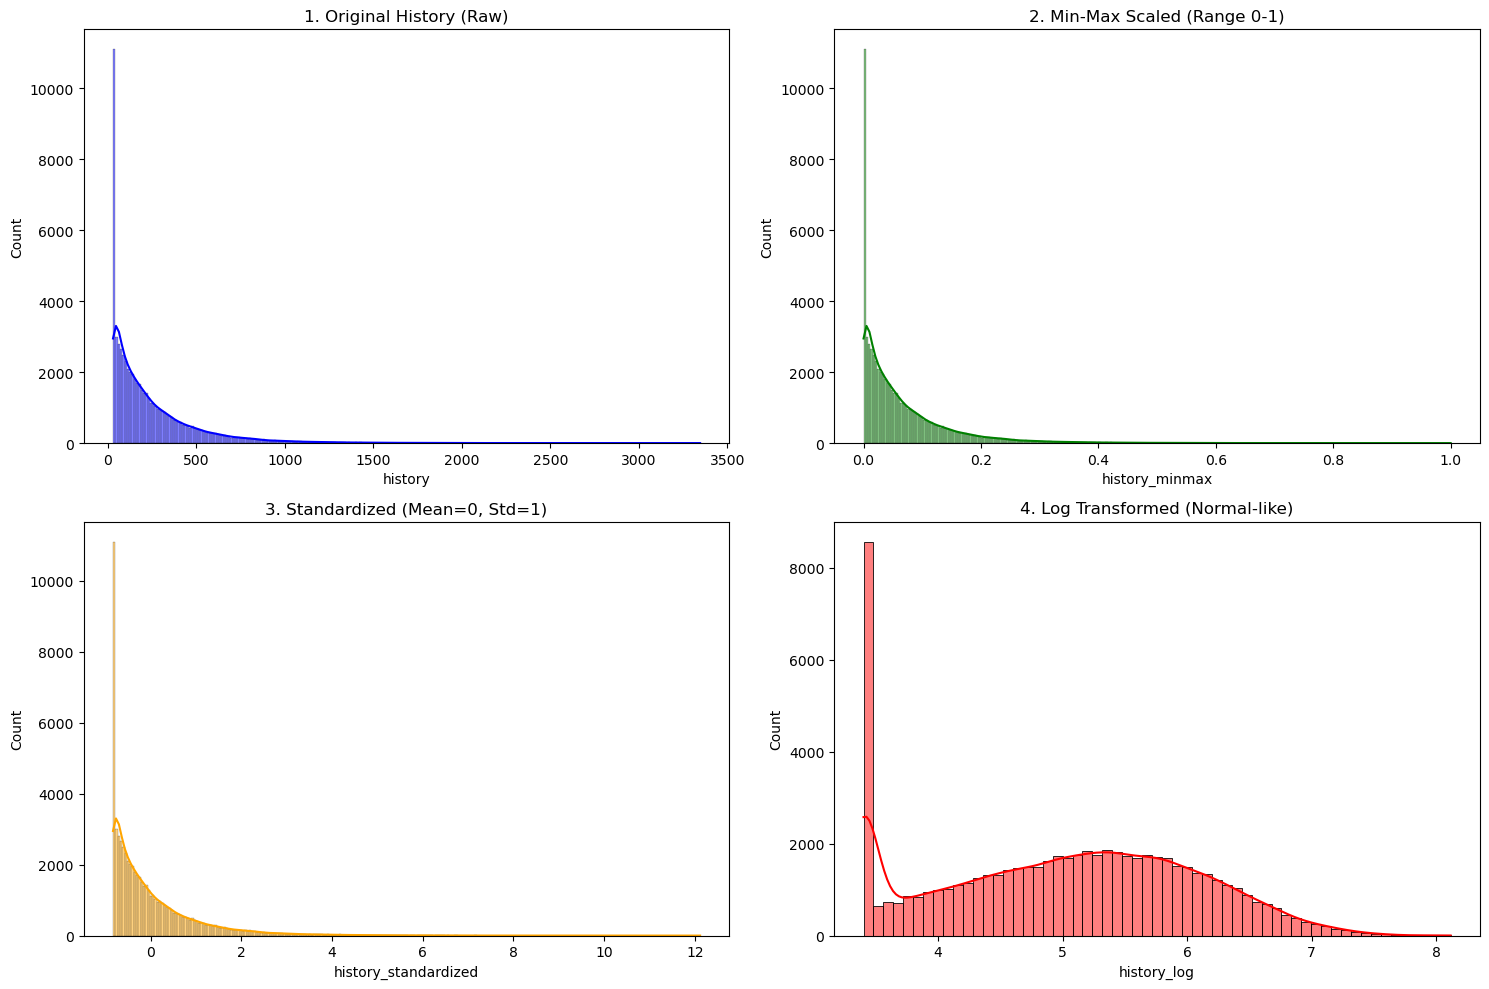

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df['history'], kde=True, ax=axes[0, 0], color='blue')

axes[0, 0].set_title('1. Original History (Raw)')
sns.histplot(df['history_minmax'], kde=True, ax=axes[0, 1], color='green')

axes[0, 1].set_title('2. Min-Max Scaled (Range 0-1)')
sns.histplot(df['history_standardized'], kde=True, ax=axes[1, 0], color='orange')

axes[1, 0].set_title('3. Standardized (Mean=0, Std=1)')
sns.histplot(df['history_log'], kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('4. Log Transformed (Normal-like)')
plt.tight_layout()
plt.show()

**What do you observe applying scaling and standardization?**

min o max and standardize only changed the number sizes  but log scaling fixed the skewd shape into a balanced bell curve.